In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
#데이터 분석을 위한 기본적인 세팅이라고 생각

In [4]:
# os.environ을 이용하여 Kaggle API Username, Key 세팅하기
os.environ ['KAGGLE_USERNAME'] = 'injun25'
os.environ ['KAGGLE_KEY'] ='KGAT_4a6eaa9b7c7e22370defc27347d7603b'

In [5]:
# Linux 명령어로 Kaggle API를 이용하여 데이터셋 다운로드하기 (!kaggle ~)
# Linux 명령어로 압축 해제하기

!kaggle datasets download -d bobbyscience/league-of-legends-diamond-ranked-games-10-min
# !kaggle datasets download -d "이부분이 매번 바뀐다고 생각하면 된다."
!unzip -o league-of-legends-diamond-ranked-games-10-min.zip


Dataset URL: https://www.kaggle.com/datasets/bobbyscience/league-of-legends-diamond-ranked-games-10-min
License(s): CC0-1.0
league-of-legends-diamond-ranked-games-10-min.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  league-of-legends-diamond-ranked-games-10-min.zip
  inflating: high_diamond_ranked_10min.csv  


In [50]:
!ls

heart-failure-clinical-data.zip		    xAPI-Edu-Data.csv
heart_failure_clinical_records_dataset.csv  xAPI-Edu-Data.zip
sample_data


In [6]:
# pd.read_csv()로 csv파일 읽어들이기
df = pd.read_csv('high_diamond_ranked_10min.csv')

In [7]:
df.head()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


In [8]:
df.columns

Index(['gameId', 'blueWins', 'blueWardsPlaced', 'blueWardsDestroyed',
       'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists',
       'blueEliteMonsters', 'blueDragons', 'blueHeralds',
       'blueTowersDestroyed', 'blueTotalGold', 'blueAvgLevel',
       'blueTotalExperience', 'blueTotalMinionsKilled',
       'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff',
       'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed',
       'redFirstBlood', 'redKills', 'redDeaths', 'redAssists',
       'redEliteMonsters', 'redDragons', 'redHeralds', 'redTowersDestroyed',
       'redTotalGold', 'redAvgLevel', 'redTotalExperience',
       'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redGoldDiff',
       'redExperienceDiff', 'redCSPerMin', 'redGoldPerMin'],
      dtype='object')

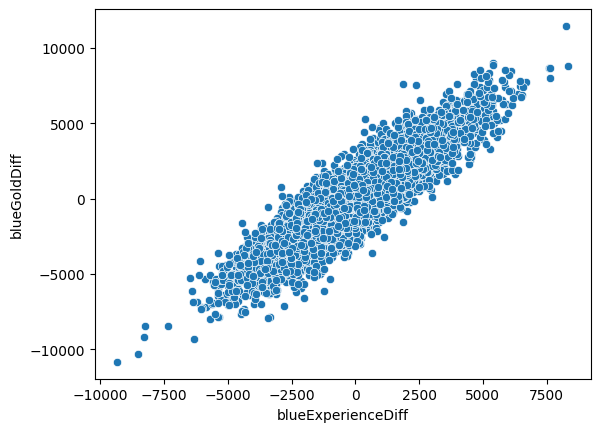

In [25]:
sns.scatterplot(x=df.blueExperienceDiff, y=df.blueGoldDiff)
plt.show()

선형회귀분석

In [11]:
import numpy as np

class LinearRegression:
    def __init__(self):
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        
        X = np.hstack((np.ones((X.shape[0], 1)), X))

      
        self.weights = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

       
        self.bias = self.weights[0]
        self.weights = self.weights[1:]

    def predict(self, X):
        
        X = np.hstack((np.ones((X.shape[0], 1)), X))

        
        y_pred = X.dot(np.hstack((self.bias, self.weights)))

        return y_pred

In [12]:
def train_test_split(dataframe, test_size=0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)

    
    indices = np.random.permutation(len(dataframe))

    
    test_samples = int(len(dataframe) * test_size)

    
    test_indices = indices[:test_samples]
    train_indices = indices[test_samples:]

    
    train_data = dataframe.iloc[train_indices]
    test_data = dataframe.iloc[test_indices]

    return train_data, test_data

In [13]:
def mean_squared_error(y_true, y_pred):
    
    squared_errors = [(y_true[i] - y_pred[i]) ** 2 for i in range(len(y_true))]

    
    mse = sum(squared_errors) / len(y_true)

    return mse

In [14]:
def r_squared(y_true, y_pred):
    
    mean_y_true = sum(y_true) / len(y_true)

    
    tss = sum((y - mean_y_true) ** 2 for y in y_true)

    
    rss = sum((y_true[i] - y_pred[i]) ** 2 for i in range(len(y_true)))

    
    r2 = 1 - (rss / tss)

    return r2

In [24]:

train_data, test_data = train_test_split(df, random_state=42)

# 변수 설정
X_train = np.array(train_data.blueExperienceDiff).reshape(-1, 1)
y_train = np.array(train_data.blueGoldDiff)

X_test = np.array(test_data.blueExperienceDiff).reshape(-1, 1)
y_test = np.array(test_data.blueGoldDiff)

# 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측
predictions = model.predict(X_test)

# 평가
y_pred_train = model.predict(X_train)

print("MSE:", mean_squared_error(y_test, predictions))
print("R-squared:", r_squared(y_test, predictions))


MSE: 1111478.0519028034
R-squared: 0.8086633066195577


로지스틱회귀분석

In [19]:
import numpy as np

class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=5000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)  # 안정성을 위해서
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            # Gradient descent
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X, threshold=0.5):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        y_predicted_cls = [1 if i > threshold else 0 for i in y_predicted]
        return np.array(y_predicted_cls)



In [20]:
# 2) Train/Test Split (from scratch)
def train_test_split(dataframe, test_size=0.2, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    indices = np.random.permutation(len(dataframe))
    test_samples = int(len(dataframe) * test_size)

    test_indices = indices[:test_samples]
    train_indices = indices[test_samples:]

    train_data = dataframe.iloc[train_indices]
    test_data = dataframe.iloc[test_indices]

    return train_data, test_data





In [21]:
# 3) Accuracy
def accuracy(y_true, y_pred):
    correct = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    return correct / len(y_true)

In [23]:
# 4) Run (X = time, y = DEATH_EVENT) 
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

# 변수 설정 
X_train = np.array(train_data.blueGoldDiff).reshape(-1, 1)
y_train = np.array(train_data.blueWins)

X_test = np.array(test_data.blueGoldDiff).reshape(-1, 1)
y_test = np.array(test_data.blueWins)

# 표준화
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma[sigma == 0] = 1.0

X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma

# 모델 학습/예측/평가
model = LogisticRegression(learning_rate=0.01, n_iterations=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy(y_test, y_pred))

Accuracy: 0.7240506329113924
